# EEG Lab — Notebook 5/5
## Advanced P300 analysis with MNE-Python

**Goals**
- Discover **MNE-Python**, the reference library for EEG/MEG
- Build an MNE `Epochs` object from our data
- Plot the ERP **across all channels** and the **topography (scalp map)** of the P300
- Measure the **amplitude** and **latency** of the P300 peak
- Visualize the oddball effect with the field's standard tools

> This notebook shows how to redo, with professional tools, what we coded "by hand" in Notebook 4 — and how to go further (topographies, visual comparisons across conditions).


### 1. Load the epochs and set up MNE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne
mne.set_log_level('WARNING')   # fewer messages

epochs_arr = np.load('epochs.npy')    # (n_epochs, 8 channels, n_points)
labels = np.load('labels.npy')        # 1=standard, 2=target
time_ms = np.load('time_ms.npy')
channels = list(np.load('oddball_channels.npy'))
fs = 250

print(f"Epochs: {epochs_arr.shape} | channels: {channels}")

Epochs: (198, 8, 250) | channels: [np.str_('Fz'), np.str_('Cz'), np.str_('Pz'), np.str_('Oz'), np.str_('C3'), np.str_('C4'), np.str_('P3'), np.str_('P4')]


### 2. Build an MNE `EpochsArray` object
MNE expects the data in **volts** (our µV → ×1e-6) and needs an `info` object describing the channels and the sampling rate. We also set the **10-20 montage** so we can plot topographies.

In [2]:
# Convert uV -> V
epochs_v = epochs_arr * 1e-6

info = mne.create_info(ch_names=channels, sfreq=fs, ch_types='eeg')

# tmin = start of the epoch, in seconds (here -0.2 s)
tmin = time_ms[0] / 1000.0

# MNE events: array (n, 3) = [sample, 0, code]
events = np.column_stack([
    np.arange(len(labels)),
    np.zeros(len(labels), int),
    labels.astype(int)
])
event_id = {'standard': 1, 'target': 2}

epochs = mne.EpochsArray(epochs_v, info, events=events,
                         event_id=event_id, tmin=tmin)
epochs.set_montage('standard_1020')
print(epochs)

<EpochsArray | 198 events (all good), -0.2 – 0.796 s (baseline off), ~3.0 MiB, data loaded,
 'standard': 167
 'target': 31>


### 3. Compute the average ERPs (`evoked`)
In MNE, the average ERP is called an **`Evoked`**. We create one per condition.

In [3]:
evoked_target   = epochs['target'].average()
evoked_standard = epochs['standard'].average()

print(f"Target  : mean of {evoked_target.nave} epochs")
print(f"Standard: mean of {evoked_standard.nave} epochs")

Target  : mean of 31 epochs
Standard: mean of 167 epochs


### 4. Compare the conditions at Pz
MNE directly plots the comparison between conditions for a given electrode.

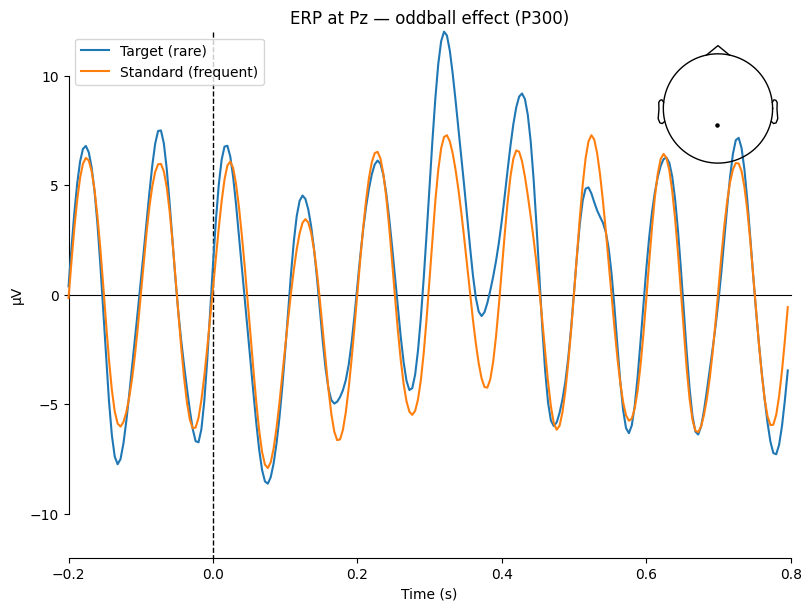

[<Figure size 800x600 with 2 Axes>]

In [4]:
mne.viz.plot_compare_evokeds(
    {'Target (rare)': evoked_target, 'Standard (frequent)': evoked_standard},
    picks='Pz', title='ERP at Pz — oddball effect (P300)',
    show=True
)

### 5. The difference (target − standard) across all channels
The difference waveform isolates the oddball effect. We plot it across the 8 channels.

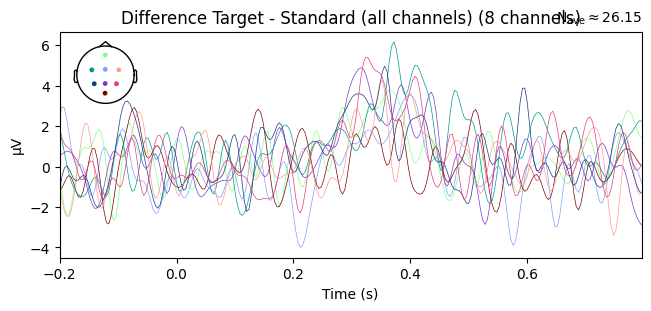

In [5]:
difference = mne.combine_evoked([evoked_target, evoked_standard], weights=[1, -1])
difference.comment = 'Target - Standard'
difference.plot(spatial_colors=True, titles='Difference Target - Standard (all channels)')
plt.show()

### 6. Topography of the P300
The **scalp map** shows where the P300 is maximal. We display it at several time points around 350 ms: we should see the **centro-parietal** maximum (Pz/Cz).

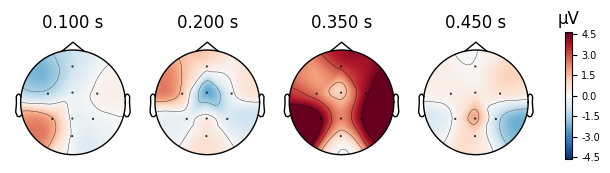

Around 350 ms, the positivity is maximal over the centro-parietal region: the P300 signature.


In [11]:
difference.plot_topomap(times=[0.1, 0.2, 0.35, 0.45], ch_type='eeg',
                        colorbar=True)
plt.show()
print("Around 350 ms, the positivity is maximal over the centro-parietal region: the P300 signature.")

### 7. Measure the P300 peak automatically
MNE finds the peak (amplitude + latency) within a given window.

In [7]:
ch, lat, amp = evoked_target.get_peak(
    ch_type='eeg', tmin=0.3, tmax=0.5, mode='pos', return_amplitude=True
)
print(f"P300 peak (target condition):")
print(f"  Electrode: {ch}")
print(f"  Latency  : {lat*1000:.0f} ms")
print(f"  Amplitude: {amp*1e6:.2f} uV")

P300 peak (target condition):
  Electrode: P4
  Latency  : 328 ms
  Amplitude: 13.00 uV


### 8. Overview: target ERP across all electrodes
A final "joint" view: waveforms of all channels + topographies at key time points.

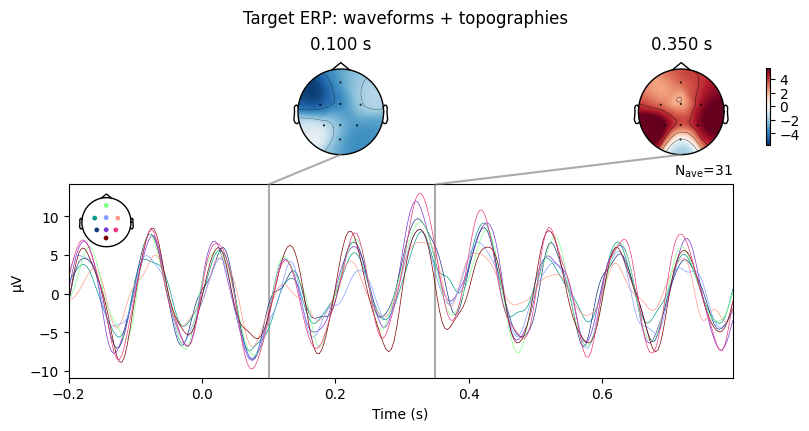

In [8]:
evoked_target.plot_joint(times=[0.1, 0.35],
                         title='Target ERP: waveforms + topographies')
plt.show()

---
### ✏️ Exercises
1. Redo `get_peak` for the **standard** condition. Is the amplitude lower?
2. Display the topography of the **target** condition alone (not the difference). What do you notice before 200 ms?
3. With `plot_compare_evokeds`, compare the conditions at **Oz** instead of Pz. Is the oddball effect present there?

### 🔑 Key takeaways
- MNE structures the analysis around the **`Epochs`** and **`Evoked`** (average ERP) objects.
- Data must be in **volts** and associated with a **montage** for topographies.
- The **topography** confirms the **centro-parietal** location of the P300.
- `get_peak` objectively measures the **amplitude** and **latency** of the peak.

### 🎓 Series recap
1. Simulation of an oddball paradigm (triggers on the D11 channel)
2. Python basics + loading and exploring the data
3. Filtering suited to ERPs (0.1–30 Hz + 50 Hz notch)
4. Epoching, baseline, artifact rejection, averaging → the P300 emerges
5. Advanced analysis with MNE: topography, amplitude, latency

You have gone through the whole chain: from the raw signal to the measurement of a cognitive response.
